<a href="https://colab.research.google.com/github/rahiakela/ai-agents-research-and-practice/blob/main/ai-agents-and-applications/part-1-summarization/01_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [ ]:
!wget https://github.com/roberto-inf/building-llm-applications/raw/main/ch03/Moby-Dick.txt

In [ ]:
!pip install langchain-google-genai
!pip install langchain-text-splitters
!pip install langchain_community
!pip install wikipedia
!pip install docx2txt

In [ ]:
!pip install "unstructured[all-docs]"

In [1]:
from langchain_text_splitters import TokenTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableParallel
from langchain_core.prompts import PromptTemplate

In [2]:
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.document_loaders import Docx2txtLoader
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import TextLoader

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings

import os
from google.colab import userdata

In [4]:
# --- Configuration ---
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

In [5]:
# Initialize the ChatGoogleGenerativeAI model
# Use a model that supports audio input, like "gemini-1.5-flash" or "gemini-1.5-pro"
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    streaming=True,
    api_key=userdata.get("GOOGLE_API_KEY")
)

gemini_embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

## MapReduce Technique

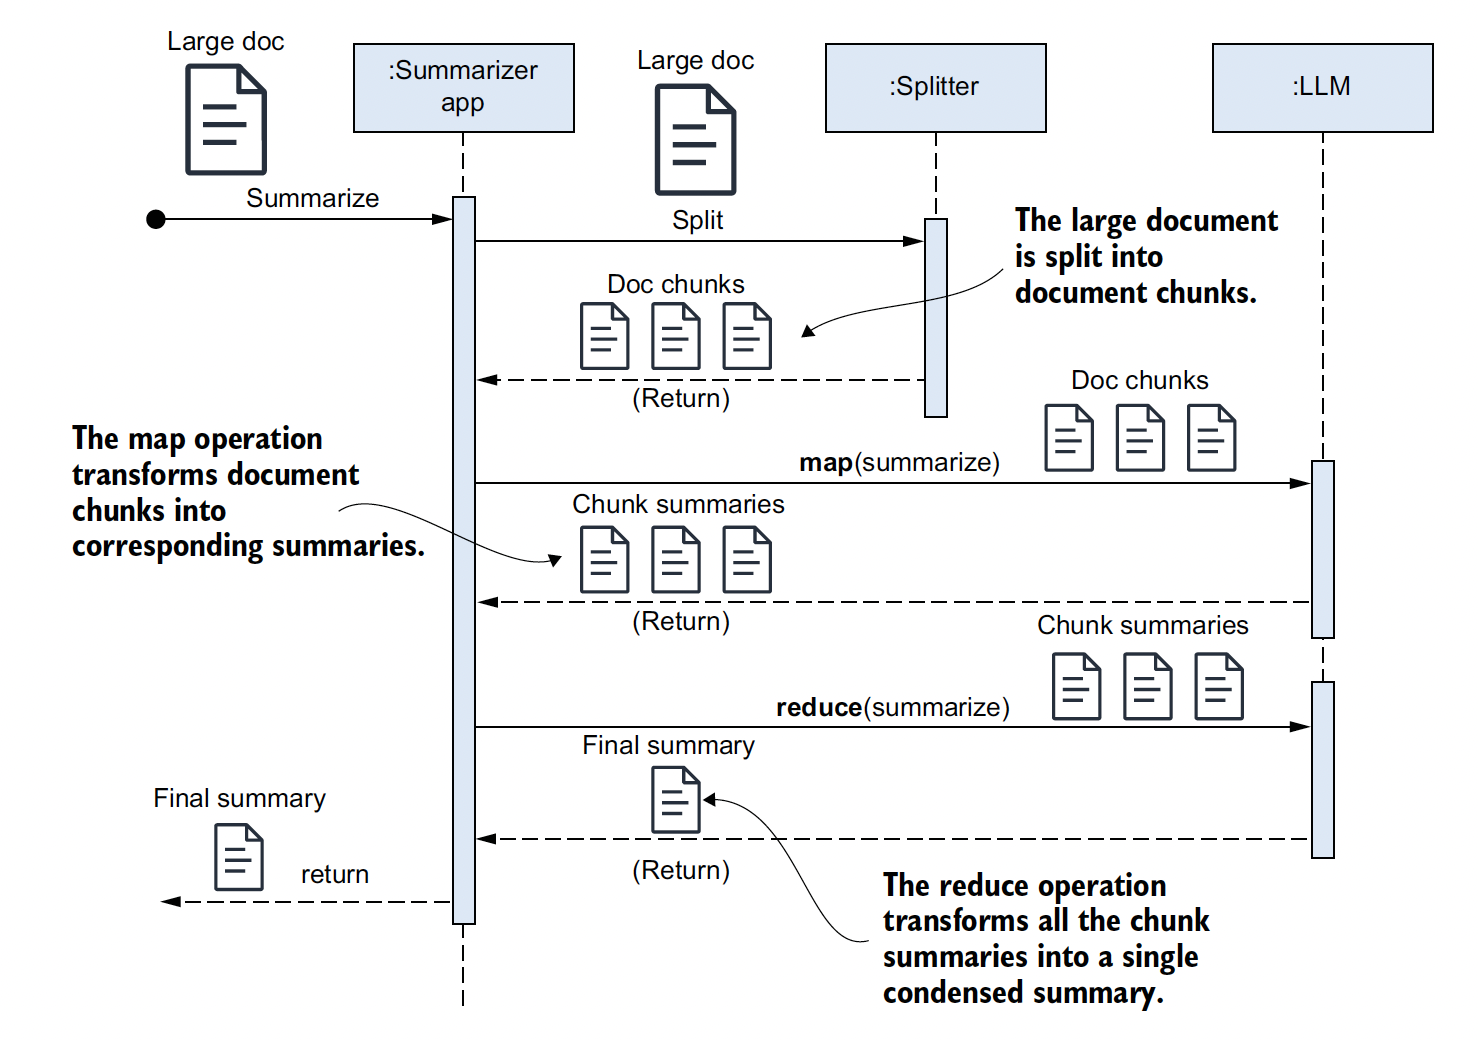

### Load document

In [6]:
with open("./Moby-Dick.txt", 'r', encoding='utf-8') as f:
    moby_dick_book = f.read()

### Split document

In [32]:
# Split
text_chunks_chain = (
    RunnableLambda(lambda x:
        [
            {
                'chunk': text_chunk,
            }
            for text_chunk in TokenTextSplitter(
                chunk_size=3000,
                chunk_overlap=100
            ).split_text(x)
        ]
    )
)

### Map document

In [8]:
# Map
summarize_chunk_prompt_template = """
Write a concise summary of the following text, and include the main details.
Text: {chunk}
"""

summarize_chunk_prompt = PromptTemplate.from_template(summarize_chunk_prompt_template)
summarize_chunk_chain = summarize_chunk_prompt | llm

summarize_map_chain = (
    RunnableParallel (
        {
            'summary': summarize_chunk_chain | StrOutputParser()
        }
    )
)

### Reduce document

In [9]:
# Reduce
summarize_summaries_prompt_template = """
Write a coincise summary of the following text, which joins several summaries, and include the main details.
Text: {summaries}
"""

summarize_summaries_prompt = PromptTemplate.from_template(summarize_summaries_prompt_template)
summarize_reduce_chain = (
    RunnableLambda(lambda x:
        {
            'summaries': '\n'.join([i['summary'] for i in x]),
        })
    | summarize_summaries_prompt
    | llm
    | StrOutputParser()
)

### Run MapReduce Chain

In [10]:
map_reduce_chain = (
   text_chunks_chain            # Split chain
   | summarize_map_chain.map()  # Map chain
   | summarize_reduce_chain     # Reduce chain
)

In [ ]:
summary = map_reduce_chain.invoke(moby_dick_book)

In [ ]:
print(summary)

Herman Melville's *Moby-Dick* opens with Ishmael introducing himself, explaining his recurring need to go to sea to combat profound melancholy, viewing a whaling voyage as his destiny and a "substitute for pistol and ball." Driven by an "everlasting itch for things remote," he travels to New Bedford, aiming for Nantucket.

Stranded in New Bedford, Ishmael seeks cheap lodging and finds "The Spouter Inn," a dilapidated establishment filled with whaling decor and a mysterious painting. Reluctantly assigned to share a bed with an unknown harpooneer due to the inn being full, Ishmael's apprehension grows after the landlord's bizarre explanation that his bedmate sells embalmed New Zealand heads.

Upon entering the room, Ishmael is terrified when the heavily tattooed Queequeg, carrying a preserved head, performs a pagan ritual and jumps into bed with a tomahawk. Reassured by the landlord, Ishmael overcomes his fear and agrees to share the bed. The next morning, after reflecting on his strange

## Summarizing across documents

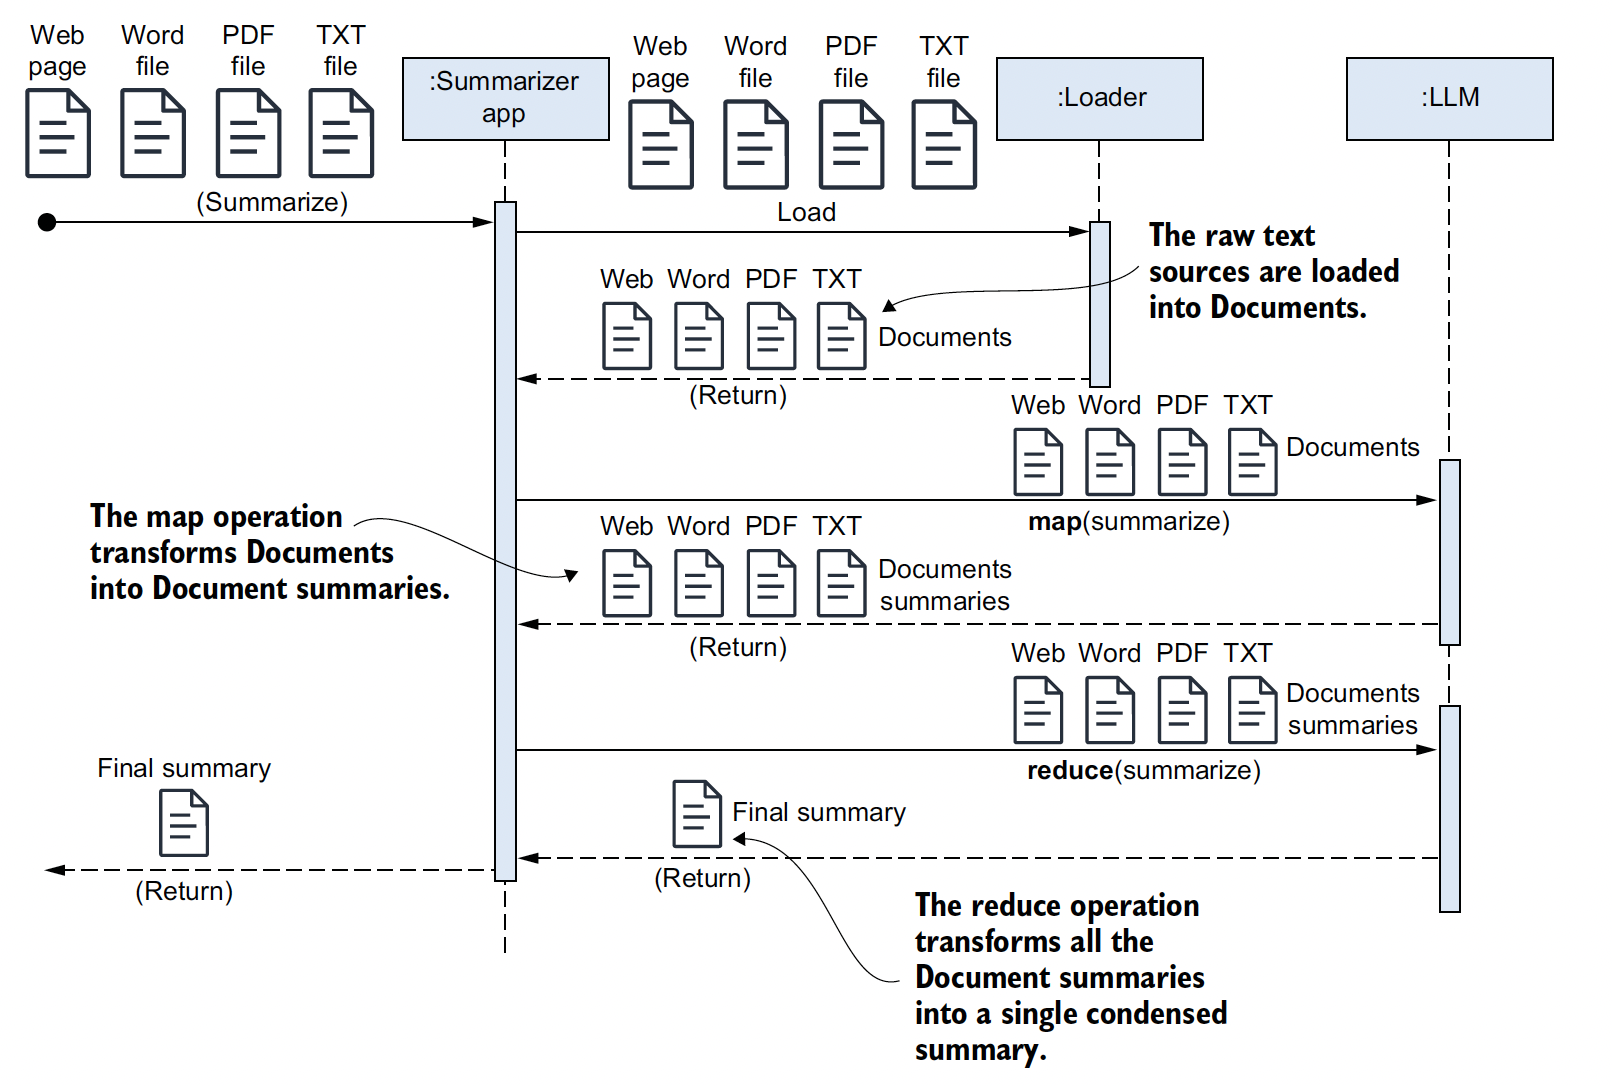

### Load document

In [ ]:
!wget https://github.com/roberto-inf/building-llm-applications/raw/main/ch03/Paestum/Paestum-Britannica.docx
!wget https://github.com/roberto-inf/building-llm-applications/raw/main/ch03/Paestum/PaestumRevisited.pdf
!wget https://github.com/roberto-inf/building-llm-applications/raw/main/ch03/Paestum/Paestum-Encyclopedia.txt

In [12]:
wikipedia_loader = WikipediaLoader(query="Paestum", load_max_docs=2)
wikipedia_docs = wikipedia_loader.load()

In [ ]:
!pip install docx2txt
word_loader = Docx2txtLoader("Paestum-Britannica.docx")
word_docs = word_loader.load()

pdf_loader = PyPDFLoader("PaestumRevisited.pdf")
pdf_docs = pdf_loader.load()

txt_loader = TextLoader("Paestum-Encyclopedia.txt")
txt_docs = txt_loader.load()

In [16]:
all_docs = wikipedia_docs + word_docs + pdf_docs + txt_docs

In [29]:
all_page_contents = [doc.page_content for doc in all_docs]

### Summarize document

In [69]:
summary = map_reduce_chain.invoke(all_page_contents)

TypeError: expected string or buffer

In [ ]:
print(summary)

## Refinement Technique

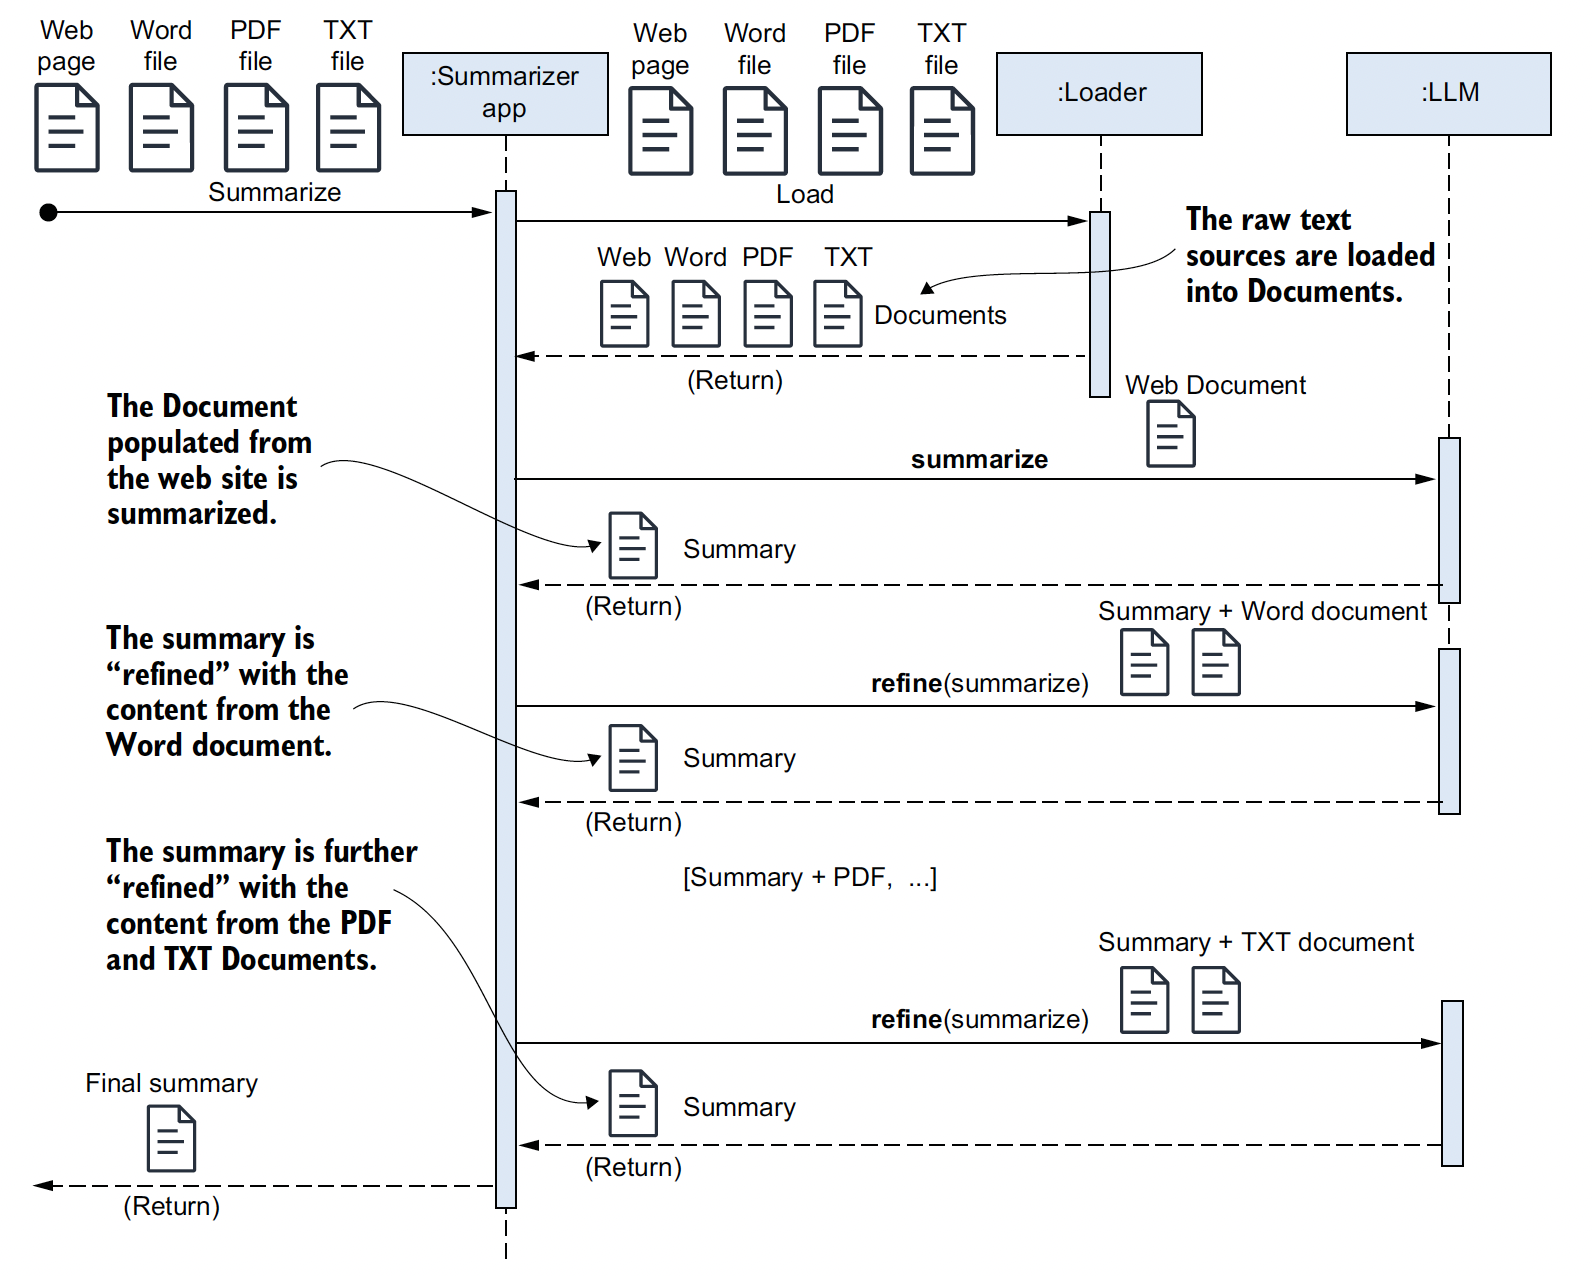

In [ ]:
doc_summary_template = """Write a concise summary of the following text:
{text}
DOC SUMMARY:"""
doc_summary_prompt = PromptTemplate.from_template(doc_summary_template)

doc_summary_chain = doc_summary_prompt | llm

In [ ]:
refine_summary_template = """
Your must produce a final summary from the current refined summary
which has been generated so far and from the content of an additional document.
This is the current refined summary generated so far: {current_refined_summary}
This is the content of the additional document: {text}
Only use the content of the additional document if it is useful,
otherwise return the current full summary as it is."""

refine_summary_prompt = PromptTemplate.from_template(refine_summary_template)

refine_chain = refine_summary_prompt | llm | StrOutputParser()

In [ ]:
def refine_summary(docs):

    intermediate_steps = []
    current_refined_summary = ''
    for doc in docs:
        intermediate_step = \
           {"current_refined_summary": current_refined_summary,
            "text": doc.page_content}
        intermediate_steps.append(intermediate_step)

        current_refined_summary = refine_chain.invoke(intermediate_step)

    return {"final_summary": current_refined_summary,
            "intermediate_steps": intermediate_steps}

In [ ]:
full_summary = refine_summary(all_docs)
print(full_summary)

{'final_summary': 'Integrated final summary (synthesizing the current refined summary with the additional document)\n\nPoseidonia/Paestum traces a long arc from a flourishing Greek urban center to a Lucanian-influenced city and finally to a Roman colonial town, with continuity in sacred spaces and intercultural exchange tempered by strategic political remodeling under Rome. The site also preserves remarkable early Greek architecture, most famously the Doric temples whose surviving ruins illuminate Paestum’s initial monumental character.\n\n1) Early core and material culture (7th–5th centuries BCE)\n- Urban and sacred framework: A fortified Greek polis with a four-gated wall, an agora north of the Hera sanctuary, the Temple of Athena, and the two Hera temples (I and II). The surviving group of Doric temples (c. 530–460 BCE) represents Paestum’s early monumental architecture. The Paestum Order—characterized by exaggerated entasis and broad, squat capitals—became a model that later Neo-Cl